<a href="https://colab.research.google.com/github/isageorgete/am-t4-s1a2026/blob/main/Tarefa_de_SVM_Redes_Neurais_e_KNN_MultiNeuralBaseCensus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline Naive Bayes | Digest GaussianiNB [Fase 1 - base_census]

## Importar dados do Drive

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Bibliotecas de Python

In [13]:
!pip -q install plotly
!pip -q install yellowbrick

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Carregar Digest de base_census

In [15]:
import pickle

In [16]:
with open ('/content/drive/MyDrive/am-t4/census.pkl', 'rb') as f:
  X_census_treinamento, Y_census_treinamento, X_census_teste, Y_census_teste = pickle.load(f)

In [17]:
X_census_treinamento.shape, Y_census_treinamento.shape

((27676, 108), (27676,))

In [18]:
X_census_teste.shape, Y_census_teste.shape

((4885, 108), (4885,))

In [19]:
from sklearn.naive_bayes import GaussianNB

In [20]:
naive_census_data = GaussianNB()
naive_census_data.fit(X_census_treinamento, Y_census_treinamento)

GaussianNB()

## Criando base Previsora

In [21]:
census_predict = naive_census_data.predict(X_census_teste)

In [22]:
census_predict #camada sintetica de navbaws- camada virtual

array([' >50K', ' >50K', ' >50K', ..., ' <=50K', ' >50K', ' >50K'],
      dtype='<U6')

In [23]:
Y_census_teste #realidade

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' <=50K'],
      dtype=object)

In [24]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [25]:
accuracy_score(Y_census_teste, census_predict)

0.4767656090071648

In [26]:
confusion_matrix(Y_census_teste, census_predict)

array([[1172, 2521],
       [  35, 1157]])

In [27]:
print(classification_report(Y_census_teste, census_predict))

              precision    recall  f1-score   support

       <=50K       0.97      0.32      0.48      3693
        >50K       0.31      0.97      0.48      1192

    accuracy                           0.48      4885
   macro avg       0.64      0.64      0.48      4885
weighted avg       0.81      0.48      0.48      4885



In [28]:
from yellowbrick.classifier import ConfusionMatrix

0.4767656090071648

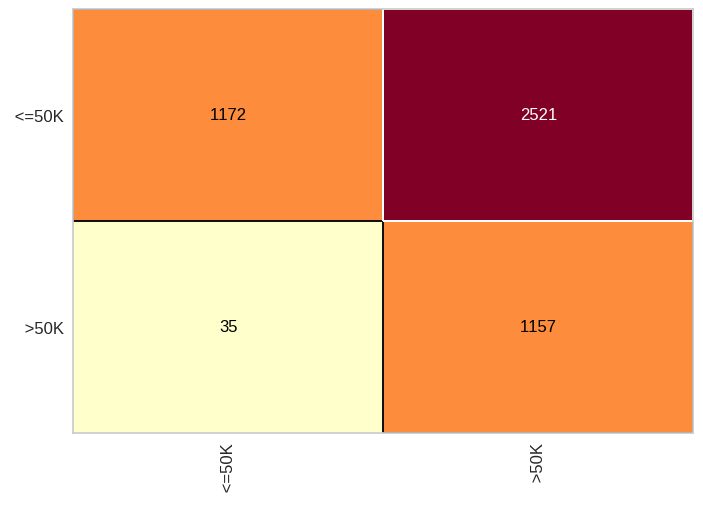

In [29]:
cm_census = ConfusionMatrix(naive_census_data)
cm_census.fit(X_census_treinamento, Y_census_treinamento)
cm_census.score(X_census_teste, Y_census_teste)

# Pipeline Arvore de Decisão |  Treemap Base [Fase 2 - base_census]

In [30]:
from sklearn.tree import DecisionTreeClassifier

In [31]:
arvore_census_data = DecisionTreeClassifier(criterion='entropy', random_state=0)
arvore_census_data.fit(X_census_treinamento, Y_census_treinamento)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [32]:
DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion = "entropy",
                       max_depth=None, max_features=None, max_leaf_nodes=None,
                       min_samples_leaf=1, min_samples_split= 2,
                       min_weight_fraction_leaf=0.0,
                       random_state=0, splitter='best')

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [33]:
previsoes_arvore = arvore_census_data.predict(X_census_teste)

In [34]:
previsoes_arvore

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype=object)

In [35]:
Y_census_teste

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' <=50K'],
      dtype=object)

# Pipeline Medições Harmonicas | Treemap Base [fase 3 - base_census]

In [36]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [37]:
accuracy_score(Y_census_teste, previsoes_arvore)

0.8104401228249745

0.8104401228249745

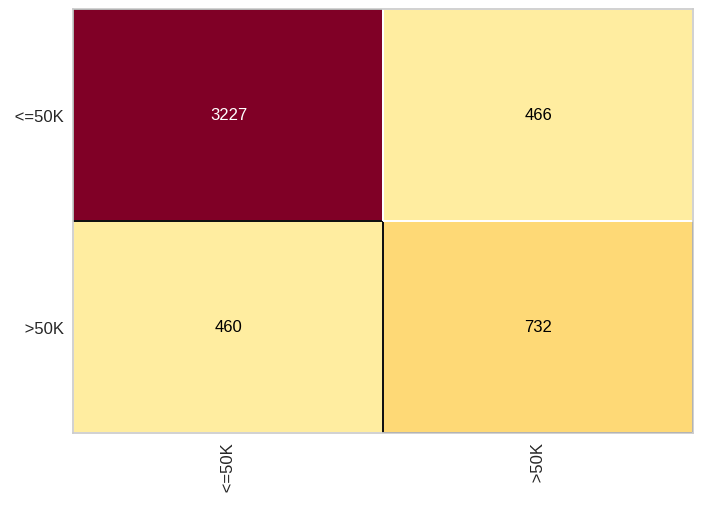

In [38]:
from  yellowbrick.classifier import ConfusionMatrix
cm_census_tree = ConfusionMatrix(arvore_census_data)
cm_census_tree.fit(X_census_treinamento, Y_census_treinamento)
cm_census_tree.score(X_census_teste, Y_census_teste)

In [39]:
print(classification_report(Y_census_teste, previsoes_arvore))

              precision    recall  f1-score   support

       <=50K       0.88      0.87      0.87      3693
        >50K       0.61      0.61      0.61      1192

    accuracy                           0.81      4885
   macro avg       0.74      0.74      0.74      4885
weighted avg       0.81      0.81      0.81      4885



# Pipeline Rondom Forest | Digest Pickle [Fase 4 - Base_census]



In [40]:
from sklearn.ensemble import RandomForestClassifier

In [41]:
random_census = RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=0)
random_census.fit(X_census_treinamento, Y_census_treinamento)
RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='entropy', max_depth=None, max_features='auto',
                       min_impurity_decrease=0.0, min_samples_split=None,
                       min_samples_leaf=1, min_weight_fraction_leaf=0.0, n_estimators=10,
                       n_jobs=None, oob_score=False, random_state=0, verbose=0, warm_start=False)

RandomForestClassifier(criterion='entropy', max_features='auto',
                       min_samples_split=None, n_estimators=10, random_state=0)

In [42]:
previsores_random = random_census.predict(X_census_teste)
previsores_random

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype=object)

## Criando base Previsora

In [43]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [44]:
accuracy_score(Y_census_teste, previsores_random)

0.8390992835209826

In [45]:
confusion_matrix(Y_census_teste, previsores_random)

array([[3419,  274],
       [ 512,  680]])

In [46]:
from yellowbrick.classifier import ConfusionMatrix

0.8390992835209826

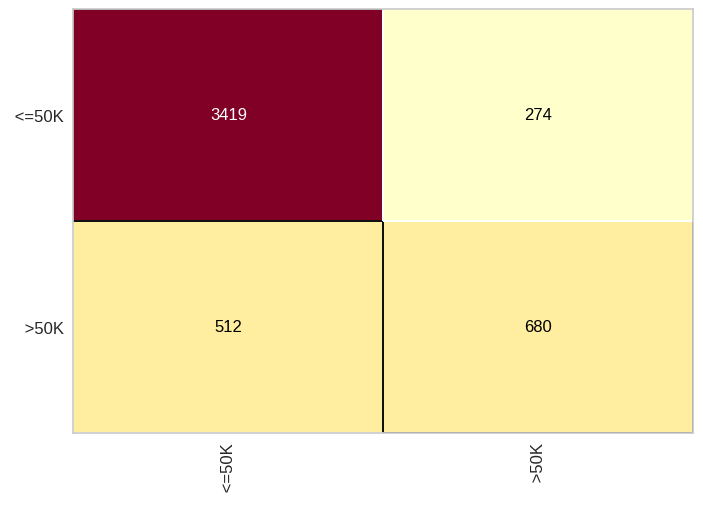

In [47]:
cm_census = ConfusionMatrix(random_census)
cm_census.fit(X_census_treinamento, Y_census_treinamento)
cm_census.score(X_census_teste, Y_census_teste)

In [48]:
print(classification_report(Y_census_teste, previsores_random))

              precision    recall  f1-score   support

       <=50K       0.87      0.93      0.90      3693
        >50K       0.71      0.57      0.63      1192

    accuracy                           0.84      4885
   macro avg       0.79      0.75      0.77      4885
weighted avg       0.83      0.84      0.83      4885



# Pipeline Regressão | Digest Pickle [Fase 5 Base_census]

In [49]:
from sklearn.linear_model import LogisticRegression

In [50]:
regressao_census = LogisticRegression(random_state=1)
regressao_census.fit(X_census_treinamento, Y_census_treinamento)

LogisticRegression(random_state=1)

In [51]:
LogisticRegression (C=1.0, class_weight=None, dual=False, fit_intercept= True,
                      intercept_scaling=1, l1_ratio= None, max_iter=100,
                      multi_class = 'auto', n_jobs = None, penalty = 'l2',
                      random_state=1, solver='lbfgs', tol=0.0001, verbose=0, warm_start=False)

LogisticRegression(multi_class='auto', random_state=1)

In [52]:
regression_previsores = regressao_census.predict(X_census_teste)
regression_previsores

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype=object)

In [53]:
accuracy_score(Y_census_teste, regression_previsores)


0.8497441146366428

0.8497441146366428

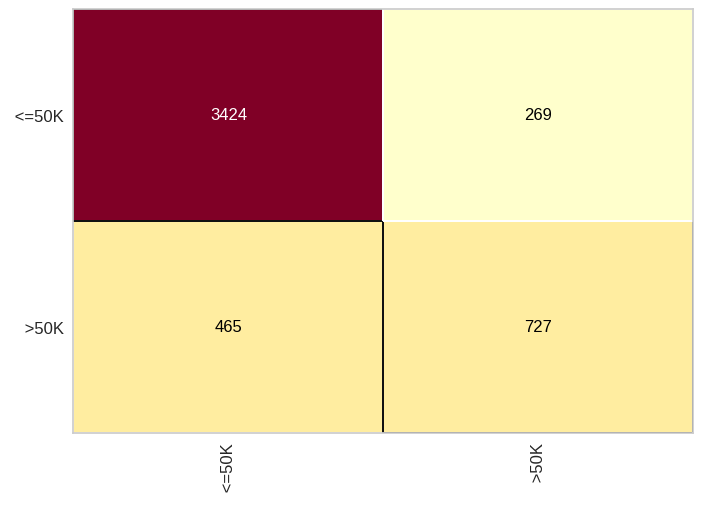

In [54]:
from yellowbrick.classifier import ConfusionMatrix
cm_census = ConfusionMatrix(regressao_census)
cm_census.fit(X_census_treinamento, Y_census_treinamento)
cm_census.score(X_census_teste, Y_census_teste)

In [55]:
print(classification_report(Y_census_teste, regression_previsores))

              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90      3693
        >50K       0.73      0.61      0.66      1192

    accuracy                           0.85      4885
   macro avg       0.81      0.77      0.78      4885
weighted avg       0.84      0.85      0.84      4885



# Pipeline SVM | Digest [Fase 6 Base Census]

In [56]:
from sklearn.svm import SVC

In [57]:
svm_census = SVC(kernel='rbf', random_state=1, C=2.0)
svm_census.fit(X_census_treinamento, Y_census_treinamento)

SVC(C=2.0, random_state=1)

In [58]:
SVC(C=2.0, break_ties=False, cache_size=200, class_weight=None, coef0=0.0,
    decision_function_shape='ovr', degree=3, gamma='scale', kernel='rbf',
    max_iter=-1, probability=False, random_state=1, shrinking=True, tol=0.001,
    verbose=False)

SVC(C=2.0, random_state=1)

In [59]:
svm_previsoes = svm_census.predict(X_census_teste)
svm_previsoes

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype=object)

In [60]:
accuracy_score(Y_census_teste, svm_previsoes)

0.8485158648925282

0.8485158648925282

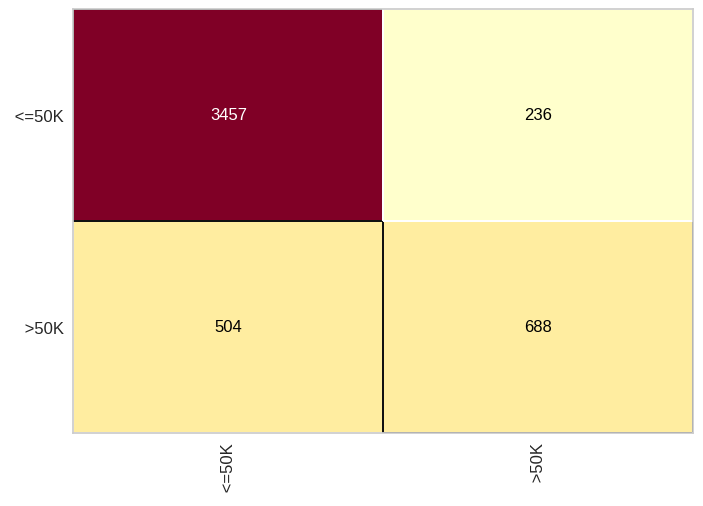

In [61]:
svm_cm = ConfusionMatrix(svm_census)
svm_cm.fit(X_census_treinamento, Y_census_treinamento)
svm_cm.score(X_census_teste, Y_census_teste)

In [62]:
print(classification_report(Y_census_teste, svm_previsoes))

              precision    recall  f1-score   support

       <=50K       0.87      0.94      0.90      3693
        >50K       0.74      0.58      0.65      1192

    accuracy                           0.85      4885
   macro avg       0.81      0.76      0.78      4885
weighted avg       0.84      0.85      0.84      4885



# Pipeline Redes Neurais | Digest [Fase 7 Base Census]

In [63]:
from sklearn.neural_network import MLPClassifier

In [64]:
redeneural_census = MLPClassifier(verbose = True, max_iter=1000,
                                  tol=0.000010, solver='adam',
                                  hidden_layer_sizes=(100), activation='relu')
redeneural_census.fit(X_census_treinamento, Y_census_treinamento)

Iteration 1, loss = 0.38569238
Iteration 2, loss = 0.32618406
Iteration 3, loss = 0.31576357
Iteration 4, loss = 0.30873331
Iteration 5, loss = 0.30429344
Iteration 6, loss = 0.30068838
Iteration 7, loss = 0.29756381
Iteration 8, loss = 0.29512757
Iteration 9, loss = 0.29321787
Iteration 10, loss = 0.29127640
Iteration 11, loss = 0.28903240
Iteration 12, loss = 0.28797155
Iteration 13, loss = 0.28620552
Iteration 14, loss = 0.28442341
Iteration 15, loss = 0.28258235
Iteration 16, loss = 0.28166280
Iteration 17, loss = 0.28049934
Iteration 18, loss = 0.27953759
Iteration 19, loss = 0.27781863
Iteration 20, loss = 0.27773510
Iteration 21, loss = 0.27652374
Iteration 22, loss = 0.27508795
Iteration 23, loss = 0.27446578
Iteration 24, loss = 0.27301033
Iteration 25, loss = 0.27228323
Iteration 26, loss = 0.27121914
Iteration 27, loss = 0.27090092
Iteration 28, loss = 0.26890303
Iteration 29, loss = 0.26860615
Iteration 30, loss = 0.26791526
Iteration 31, loss = 0.26646761
Iteration 32, los

MLPClassifier(hidden_layer_sizes=100, max_iter=1000, tol=1e-05, verbose=True)

In [65]:
redeneural_census.out_activation_

'logistic'

In [66]:
previsoes_redeneural = redeneural_census.predict(X_census_teste)
previsoes_redeneural

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype='<U6')

In [67]:
accuracy_score(Y_census_teste, previsoes_redeneural)

0.824360286591607

0.824360286591607

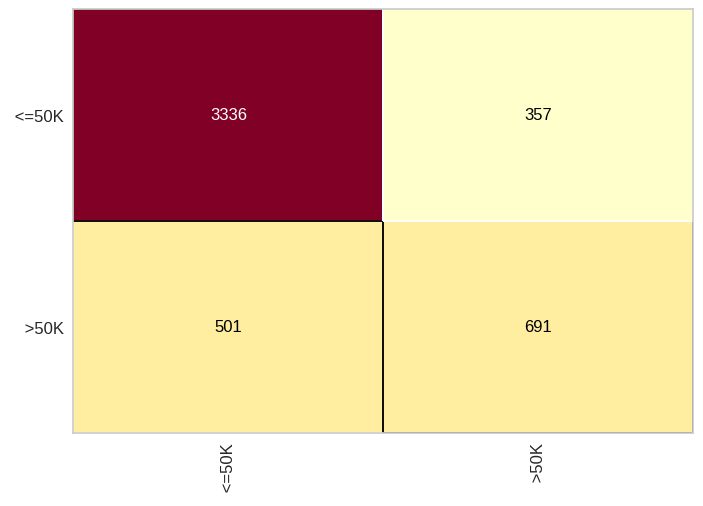

In [68]:
rn_cm = ConfusionMatrix(redeneural_census)
rn_cm.fit(X_census_treinamento, Y_census_treinamento)
rn_cm.score(X_census_teste, Y_census_teste)

In [69]:
print(classification_report(Y_census_teste, previsoes_redeneural))

              precision    recall  f1-score   support

       <=50K       0.87      0.90      0.89      3693
        >50K       0.66      0.58      0.62      1192

    accuracy                           0.82      4885
   macro avg       0.76      0.74      0.75      4885
weighted avg       0.82      0.82      0.82      4885



# Pipeline de Preparação dos Dados | Base Census [Fase 8]

In [70]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder

In [71]:
label_encoder_census = LabelEncoder()
Y_census_treinamento = label_encoder_census.fit_transform(Y_census_treinamento)

In [72]:
parametros = {'n_neighbors': [3, 5, 10, 20],
              'p':[1, 2]}

In [73]:
print(np.unique(Y_census_treinamento))

[0 1]


In [74]:
grid_census = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=parametros)
grid_census.fit(X_census_treinamento, Y_census_treinamento)
melhor_parametros_census = grid_census.best_params_
melhor_resultado_census = grid_census.best_score_
print(melhor_parametros_census)
print(melhor_resultado_census)

{'n_neighbors': 20, 'p': 1}
0.8327430212885943
